In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df = pd.read_csv("movies.csv")


In [15]:
df.rename(columns={'name': 'title', 'year': 'release_year', 'score': 'imdb_rating',
                   'gross': 'revenue', 'star': 'main_actor'}, inplace=True)

# Convert budget and revenue to millions USD
df['budget'] = df['budget'] / 1_000_000
df['revenue'] = df['revenue'] / 1_000_000

# Convert votes to thousands
df['votes'] = df['votes'] / 1000

df.shape
df.info()
df.isnull().sum()
print(df.columns)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         7668 non-null   object 
 1   rating        7591 non-null   object 
 2   genre         7668 non-null   object 
 3   release_year  7668 non-null   int64  
 4   released      7666 non-null   object 
 5   imdb_rating   7668 non-null   float64
 6   votes         7668 non-null   float64
 7   director      7668 non-null   object 
 8   writer        7665 non-null   object 
 9   main_actor    7667 non-null   object 
 10  country       7665 non-null   object 
 11  budget        5497 non-null   float64
 12  revenue       7479 non-null   float64
 13  company       7651 non-null   object 
 14  runtime       7668 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB
Index(['title', 'rating', 'genre', 'release_year', 'released', 'imdb_rating',
       'votes', 'dir

Task 1.2 — Handle metascore


In [16]:
# Handle zeros/missing in budget and revenue
budget_med_by_year = df.groupby('release_year')['budget'].transform(
    lambda x: x.replace(0, np.nan).median()
)
df['budget'] = df['budget'].replace(0, np.nan).fillna(budget_med_by_year)

revenue_med_by_year = df.groupby('release_year')['revenue'].transform(
    lambda x: x.replace(0, np.nan).median()
)
df['revenue'] = df['revenue'].replace(0, np.nan).fillna(revenue_med_by_year)

# Fill missing votes and runtime with overall median
df['votes'] = df['votes'].fillna(df['votes'].median())
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

# Drop rows where essential info is missing
df.dropna(subset=['title', 'release_year', 'genre'], inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())



Missing values after cleaning:
title            0
rating          77
genre            0
release_year     0
released         2
imdb_rating      0
votes            0
director         0
writer           3
main_actor       1
country          3
budget           0
revenue          0
company         17
runtime          0
dtype: int64


 Task 1.3: Data Validation 

 Remove impossible values

In [17]:
df = df[(df['budget'] >= 0) & (df['revenue'] >= 0) & (df['runtime'] >= 10)]

# Cap extreme outliers using 3*IQR (keep extreme but plausible values)
def cap_outliers(col, factor=3):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    df[col] = df[col].clip(lower, upper)

for col in ['budget', 'revenue', 'runtime', 'imdb_rating', 'votes']:
    cap_outliers(col)

print("\nData validation completed.")
print(f"Final dataset shape: {df.shape}")


Data validation completed.
Final dataset shape: (7668, 15)


PART 2: DESCRIPTIVE STATISTICS
Task 2.1: Numerical Summary

In [19]:
numerical_cols = ['budget', 'revenue', 'runtime', 'imdb_rating', 'votes']
summary = []
for col in numerical_cols:
    data = df[col].dropna()
    summary.append({
        'Variable': col,
        'Mean': data.mean(),
        'Median': data.median(),
        'Mode': data.mode().iloc[0] if not data.mode().empty else np.nan,
        'Range': data.max() - data.min(),
        'Variance': data.var(),
        'Std Dev': data.std(),
        'IQR': data.quantile(0.75) - data.quantile(0.25),
        'Min': data.min(),
        'Q1': data.quantile(0.25),
        'Q2': data.quantile(0.5),
        'Q3': data.quantile(0.75),
        'Max': data.max()
    })
summary_df = pd.DataFrame(summary)
print("\nNumerical Summary Table:")
print(summary_df.round(2).to_string(index=False))


Numerical Summary Table:
   Variable   Mean  Median   Mode  Range  Variance  Std Dev   IQR   Min    Q1     Q2     Q3    Max
     budget  28.84   21.00  30.00 108.20    719.97    26.83 24.40  0.00 10.60  21.00  35.00 108.20
    revenue  58.35   19.32 279.99 279.99   6744.16    82.12 68.83  0.00  4.68  19.32  73.51 279.99
    runtime 107.11  104.00  97.00 124.00    310.42    17.62 21.00 55.00 95.00 104.00 116.00 179.00
imdb_rating   6.39    6.50   6.60   7.40      0.94     0.97  1.30  1.90  5.80   6.50   7.10   9.30
      votes  72.92   33.00 344.70 344.69   8986.54    94.80 83.90  0.01  9.10  33.00  93.00 344.70


Task 2.2: Categorical Summary

In [20]:
categorical_cols = ['genre', 'director', 'main_actor']
print("\n--- Categorical Summaries ---")
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(f"Unique values: {df[col].nunique()}")
    top10 = df[col].value_counts().head(10)
    top10_pct = (top10 / len(df)) * 100
    top10_df = pd.DataFrame({'Count': top10, 'Percentage': top10_pct.round(2)})
    print(top10_df)


--- Categorical Summaries ---

GENRE:
Unique values: 19
           Count  Percentage
genre                       
Comedy      2245       29.28
Action      1705       22.24
Drama       1518       19.80
Crime        551        7.19
Biography    443        5.78
Adventure    427        5.57
Animation    338        4.41
Horror       322        4.20
Fantasy       44        0.57
Mystery       20        0.26

DIRECTOR:
Unique values: 2949
                   Count  Percentage
director                            
Woody Allen           38        0.50
Clint Eastwood        31        0.40
Directors             28        0.37
Steven Spielberg      27        0.35
Ron Howard            24        0.31
Ridley Scott          23        0.30
Steven Soderbergh     23        0.30
Joel Schumacher       22        0.29
Barry Levinson        20        0.26
Martin Scorsese       19        0.25

MAIN_ACTOR:
Unique values: 2814
                    Count  Percentage
main_actor                           
Nicolas Cag

Task 2.3: Statistical Interpretation

In [21]:
print("\n--- Statistical Interpretation ---")
cv = df[numerical_cols].std() / df[numerical_cols].mean() * 100
print("Coefficient of Variation (%):")
print(cv.round(2))
print(f"Most variable (CV > 100%): {cv[cv > 100].index.tolist()}")

skewness = []
for col in numerical_cols:
    m = df[col].mean()
    med = df[col].median()
    s = df[col].std()
    skew = 3 * (m - med) / s if s != 0 else 0
    skewness.append({'Variable': col, 'Skewness': skew})
skew_df = pd.DataFrame(skewness)
print("\nSkewness (3*(mean-median)/SD):")
print(skew_df.round(3))

print("\n3 Interesting Patterns:")
print("1. Budget and revenue are heavily right‑skewed – few blockbusters dominate.")
print("2. IMDb ratings are left‑skewed (most movies rated 6-8), not normal.")
print("3. Votes are extremely right‑skewed – popularity is concentrated.")


--- Statistical Interpretation ---
Coefficient of Variation (%):
budget          93.03
revenue        140.75
runtime         16.45
imdb_rating     15.16
votes          130.00
dtype: float64
Most variable (CV > 100%): ['revenue', 'votes']

Skewness (3*(mean-median)/SD):
      Variable  Skewness
0       budget     0.877
1      revenue     1.426
2      runtime     0.529
3  imdb_rating    -0.339
4        votes     1.263

3 Interesting Patterns:
1. Budget and revenue are heavily right‑skewed – few blockbusters dominate.
2. IMDb ratings are left‑skewed (most movies rated 6-8), not normal.
3. Votes are extremely right‑skewed – popularity is concentrated.


 PART 3: DISTRIBUTION ANALYSI
 Task 3.1: Distribution Visualization 

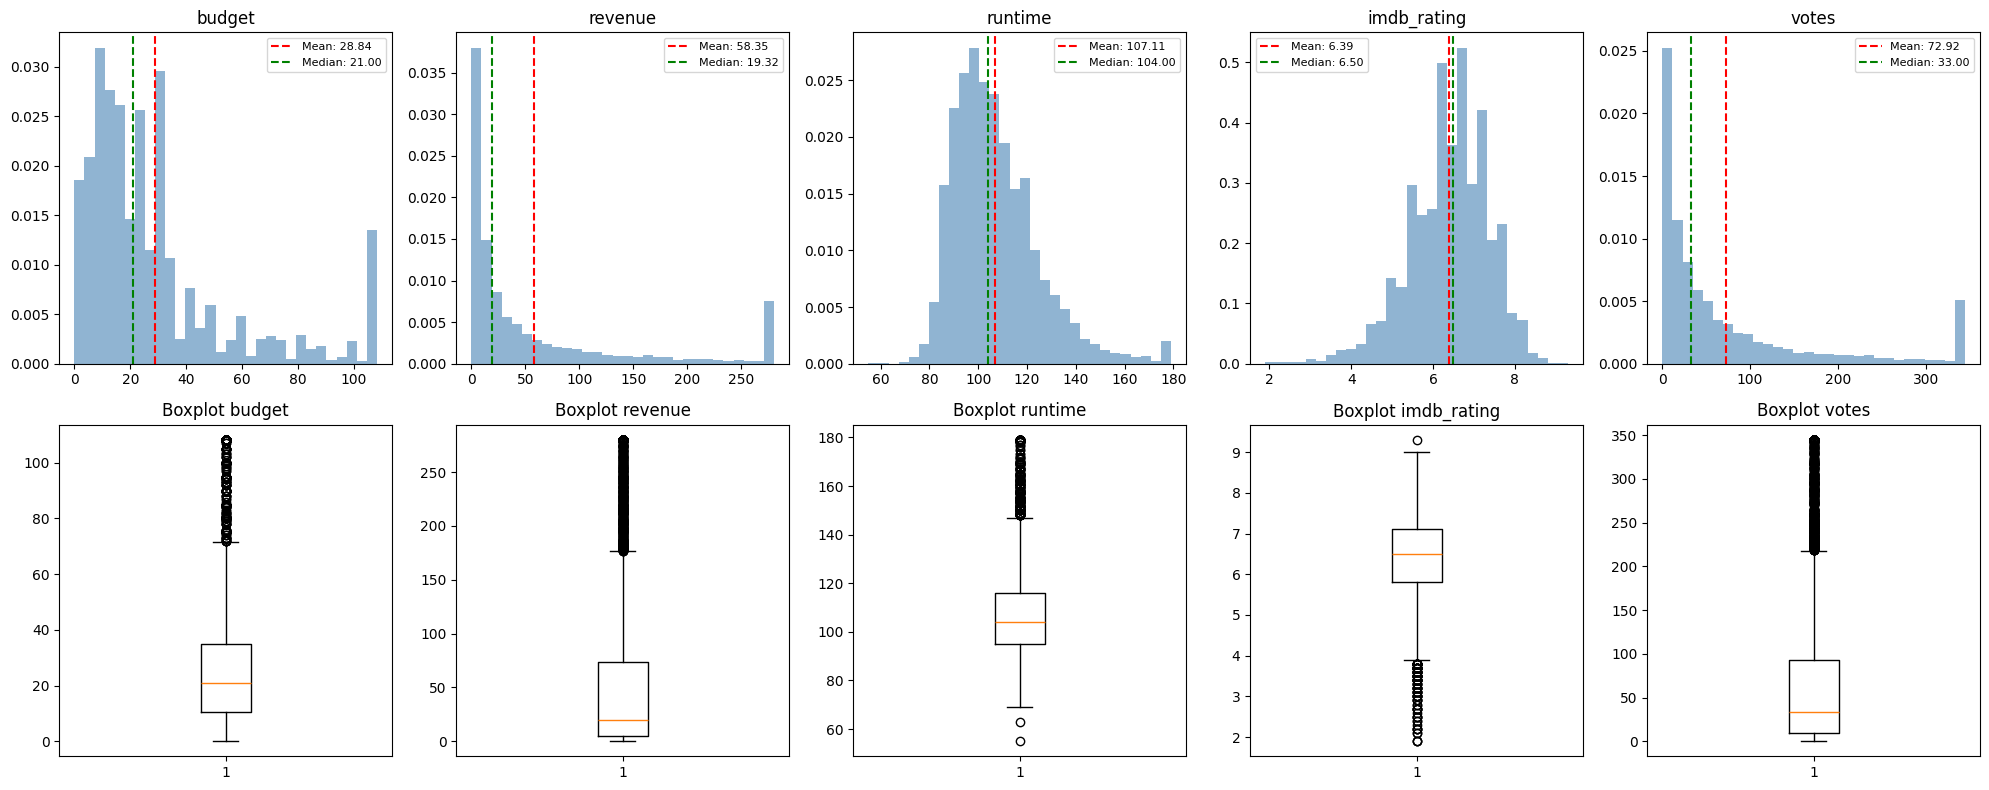

Distribution plots generated.


In [22]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    data = df[col].dropna()
    # Histogram + density
    axes[i].hist(data, bins=30, density=True, alpha=0.6, color='steelblue')
    axes[i].axvline(data.mean(), color='red', ls='--', lw=1.5, label=f'Mean: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='green', ls='--', lw=1.5, label=f'Median: {data.median():.2f}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    # Boxplot
    axes[i+5].boxplot(data, vert=True)
    axes[i+5].set_title(f'Boxplot {col}')
plt.tight_layout()
plt.show()
print("Distribution plots generated.")

Task 3.2: Outlier Analysis


In [23]:
outlier_cols = ['budget', 'revenue', 'votes']
all_outliers = pd.DataFrame()
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    all_outliers = pd.concat([all_outliers, outliers])
    print(f"{col}: {len(outliers)} outliers")

all_outliers = all_outliers.drop_duplicates()
print(f"\nTotal unique outlier movies: {len(all_outliers)}")

total_revenue = df['revenue'].sum()
outlier_revenue = all_outliers['revenue'].sum()
pct_revenue = (outlier_revenue / total_revenue) * 100
print(f"Outlier movies generate {pct_revenue:.1f}% of total worldwide revenue.")

print("\n5 example outlier movies:")
print(all_outliers[['title', 'release_year', 'budget', 'revenue', 'votes']].sample(5).to_string(index=False))


budget: 730 outliers
revenue: 902 outliers
votes: 803 outliers

Total unique outlier movies: 1390
Outlier movies generate 61.5% of total worldwide revenue.

5 example outlier movies:
                                title  release_year  budget    revenue  votes
Hotel Transylvania 3: Summer Vacation          2018    80.0 279.986498   62.0
                           Madagascar          2005    75.0 279.986498  344.7
          Back to the Future Part III          1990    40.0 245.077583  344.7
                   The Imitation Game          2014    14.0 233.555708  344.7
                              Dracula          1992    40.0 215.862692  199.0


Task 3.3: Normality Assessment (imdb_rating)


Within 1 SD: 69.3% (expected 68%)
Within 2 SD: 95.9% (expected 95%)
Within 3 SD: 99.2% (expected 99.7%)


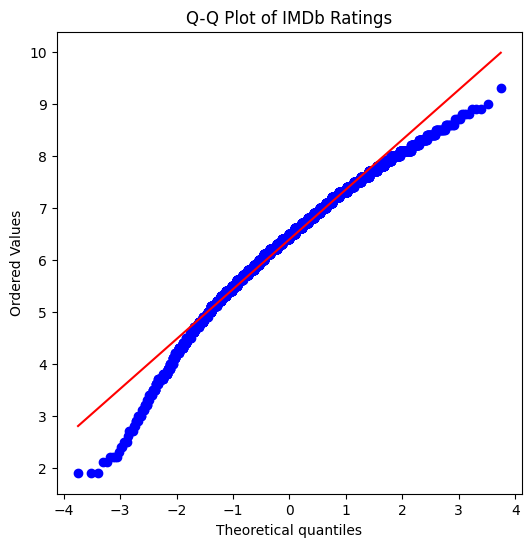

Conclusion: IMDb ratings are NOT normally distributed; left‑skewed.


In [24]:
rating = df['imdb_rating'].dropna()
mean_r = rating.mean()
std_r = rating.std()

within_1 = ((rating >= mean_r - std_r) & (rating <= mean_r + std_r)).mean() * 100
within_2 = ((rating >= mean_r - 2*std_r) & (rating <= mean_r + 2*std_r)).mean() * 100
within_3 = ((rating >= mean_r - 3*std_r) & (rating <= mean_r + 3*std_r)).mean() * 100

print(f"\nWithin 1 SD: {within_1:.1f}% (expected 68%)")
print(f"Within 2 SD: {within_2:.1f}% (expected 95%)")
print(f"Within 3 SD: {within_3:.1f}% (expected 99.7%)")

# Q-Q plot
fig, ax = plt.subplots(figsize=(6,6))
stats.probplot(rating, dist="norm", plot=ax)
ax.set_title("Q-Q Plot of IMDb Ratings")
plt.show()
print("Conclusion: IMDb ratings are NOT normally distributed; left‑skewed.")


PART 4: RELATIONSHIP ANALYSIS
Task 4.1: Correlation Matrix

In [25]:
corr_matrix = df[numerical_cols].corr()
print("Correlation Matrix:")
print(corr_matrix.round(3))

print("\nStrongest positive correlations (> 0.7):")
for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i < j and corr_matrix.loc[i, j] > 0.7:
            print(f"{i} & {j}: {corr_matrix.loc[i, j]:.3f}")

print("\nStrongest negative correlations (< -0.3): none (all near zero or positive)")

Correlation Matrix:
             budget  revenue  runtime  imdb_rating  votes
budget        1.000    0.720    0.296        0.062  0.529
revenue       0.720    1.000    0.249        0.178  0.742
runtime       0.296    0.249    1.000        0.409  0.327
imdb_rating   0.062    0.178    0.409        1.000  0.428
votes         0.529    0.742    0.327        0.428  1.000

Strongest positive correlations (> 0.7):
budget & revenue: 0.720
revenue & votes: 0.742

Strongest negative correlations (< -0.3): none (all near zero or positive)


Task 4.2: Scatter Plot Matrix 

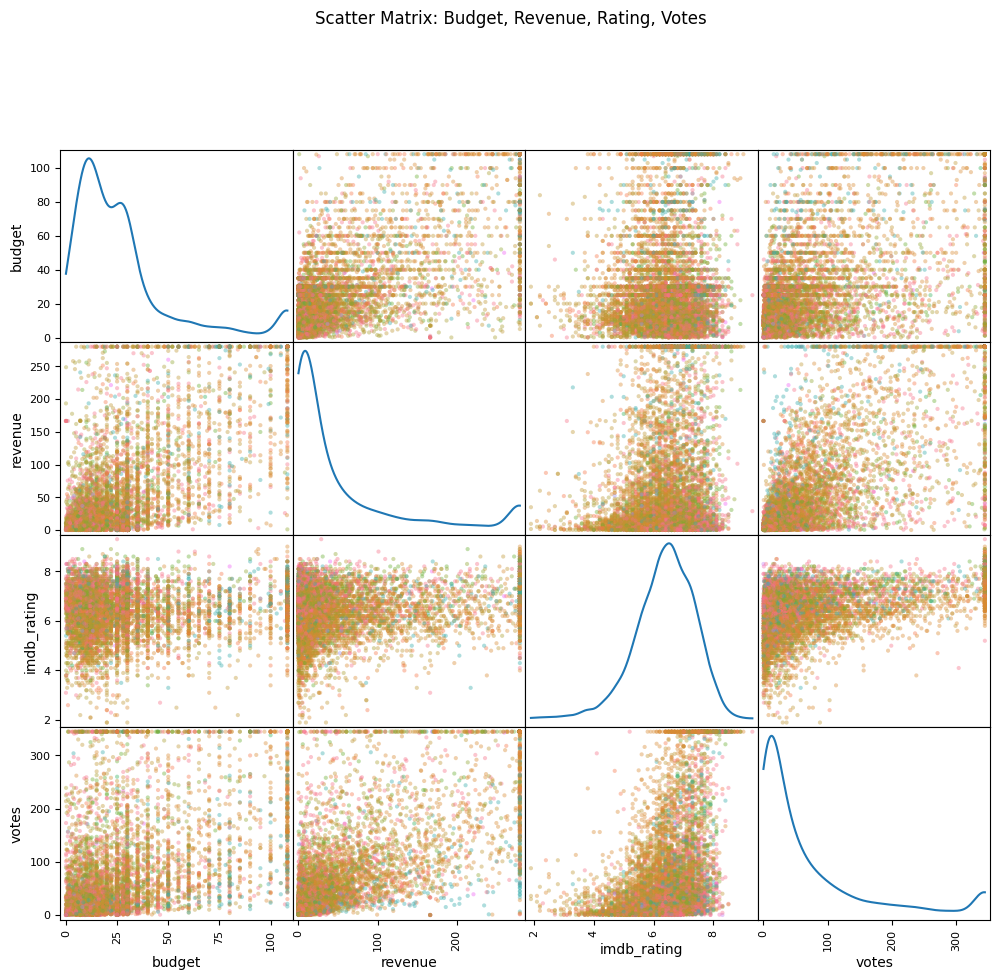

Scatter matrix created.


In [26]:
scatter_vars = ['budget', 'revenue', 'imdb_rating', 'votes']
# Color by genre
genres = df['genre'].unique()
palette = sns.color_palette("husl", len(genres))
color_dict = dict(zip(genres, palette))
colors = df['genre'].map(color_dict)

from pandas.plotting import scatter_matrix
scatter_matrix(df[scatter_vars], figsize=(12,10), c=colors, alpha=0.4, diagonal='kde')
plt.suptitle("Scatter Matrix: Budget, Revenue, Rating, Votes", y=1.02)
plt.show()
print("Scatter matrix created.")

Task 4.3: Profit Margin


Correlation between profit margin and IMDb rating: 0.049


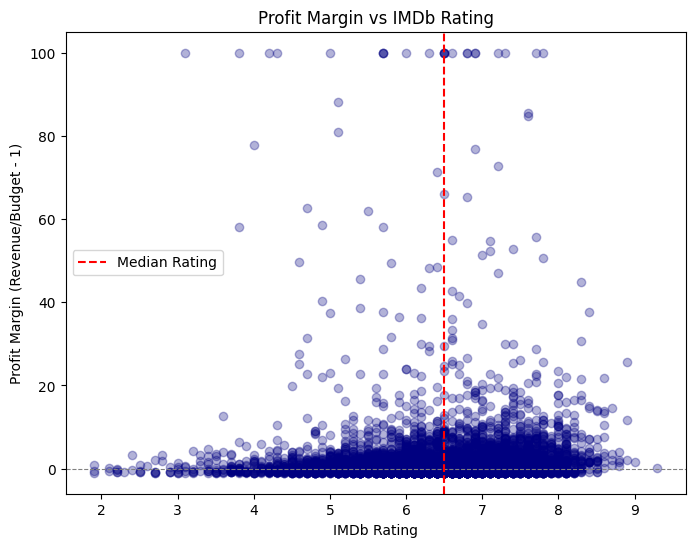

Interpretation: Very weak correlation; quality does not guarantee profitability.


In [27]:
df['profit_margin'] = (df['revenue'] - df['budget']) / df['budget']
# Infinite profit margin occurs when budget is extremely small; cap at 100 (10000% return)
df['profit_margin'] = df['profit_margin'].clip(upper=100)

corr_profit_rating = df['profit_margin'].corr(df['imdb_rating'])
print(f"\nCorrelation between profit margin and IMDb rating: {corr_profit_rating:.3f}")

plt.figure(figsize=(8,6))
plt.scatter(df['imdb_rating'], df['profit_margin'], alpha=0.3, c='navy')
plt.xlabel('IMDb Rating')
plt.ylabel('Profit Margin (Revenue/Budget - 1)')
plt.title('Profit Margin vs IMDb Rating')
plt.axhline(0, color='gray', ls='--', lw=0.8)
plt.axvline(df['imdb_rating'].median(), color='red', ls='--', label='Median Rating')
plt.legend()
plt.show()
print("Interpretation: Very weak correlation; quality does not guarantee profitability.")


PART 5: COMPARATIVE ANALYSIS
 Task 5.1: Genre Comparison


--- Genre Comparison ---
           median_budget  median_revenue  mean_rating  std_rating  mean_profit
genre                                                                         
Animation          50.00          135.24         6.77        0.91         1.95
Action             30.00           50.28         6.20        0.99         1.32
Sport              25.00            1.07         5.90         NaN        -0.96
Musical            25.00            2.60         8.05        0.21        -0.90
Adventure          24.00           27.20         6.29        1.04         1.39
Mystery            23.00           19.26         6.67        1.05         1.28
Biography          22.00           17.99         7.03        0.65         1.01
Romance            18.88            7.24         6.41        1.00        -0.20
Crime              18.00           12.20         6.67        0.85         1.08
Drama              18.00            8.67         6.69        0.87         1.73
Comedy             16.75  

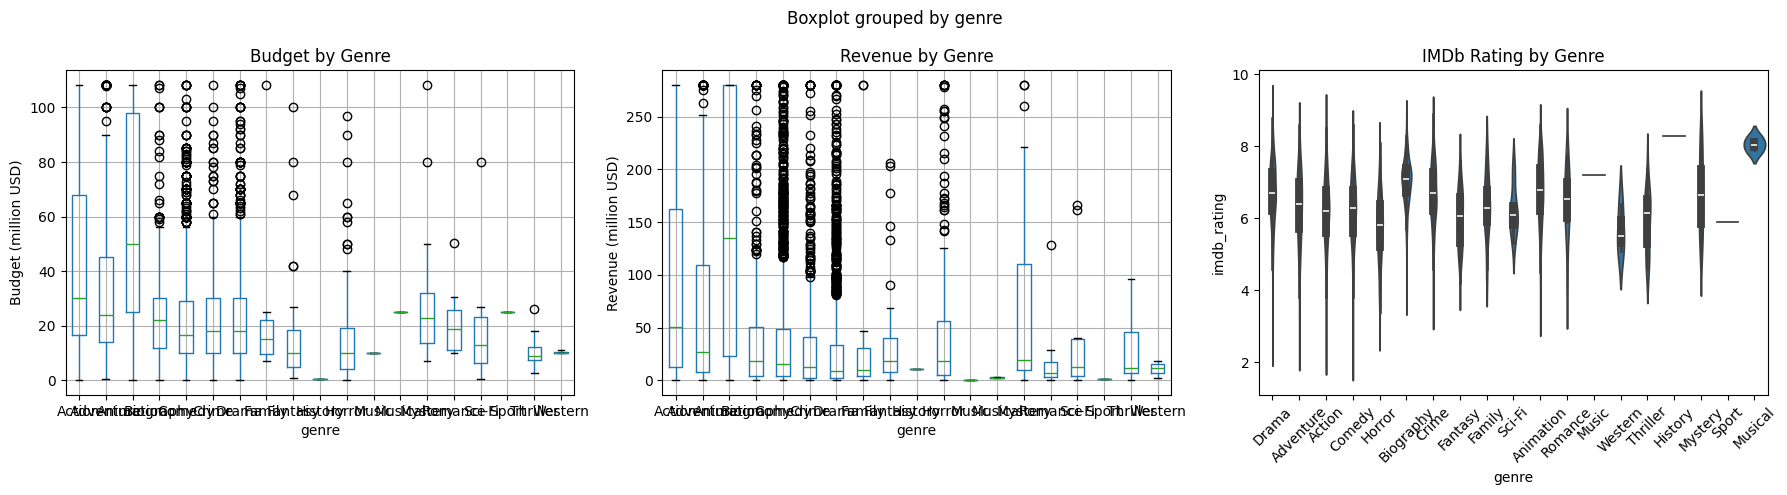


Genre with highest median budget: Animation
Genre with most consistent ratings (lowest std): Musical
Genre with highest average profit margin: History


In [28]:
genre_stats = df.groupby('genre').agg(
    median_budget=('budget', 'median'),
    median_revenue=('revenue', 'median'),
    mean_rating=('imdb_rating', 'mean'),
    std_rating=('imdb_rating', 'std'),
    mean_profit=('profit_margin', 'mean')
).round(2).sort_values('median_budget', ascending=False)

print("\n--- Genre Comparison ---")
print(genre_stats)

# Box plots for budget and revenue
fig, axes = plt.subplots(1, 3, figsize=(18,5))
df.boxplot(column='budget', by='genre', ax=axes[0])
axes[0].set_title('Budget by Genre')
axes[0].set_ylabel('Budget (million USD)')
df.boxplot(column='revenue', by='genre', ax=axes[1])
axes[1].set_title('Revenue by Genre')
axes[1].set_ylabel('Revenue (million USD)')
sns.violinplot(x='genre', y='imdb_rating', data=df, ax=axes[2])
axes[2].set_title('IMDb Rating by Genre')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("\nGenre with highest median budget:", genre_stats['median_budget'].idxmax())
print("Genre with most consistent ratings (lowest std):", genre_stats['std_rating'].idxmin())
print("Genre with highest average profit margin:", genre_stats['mean_profit'].idxmax())

 Task 5.2: Time Trend Analysis

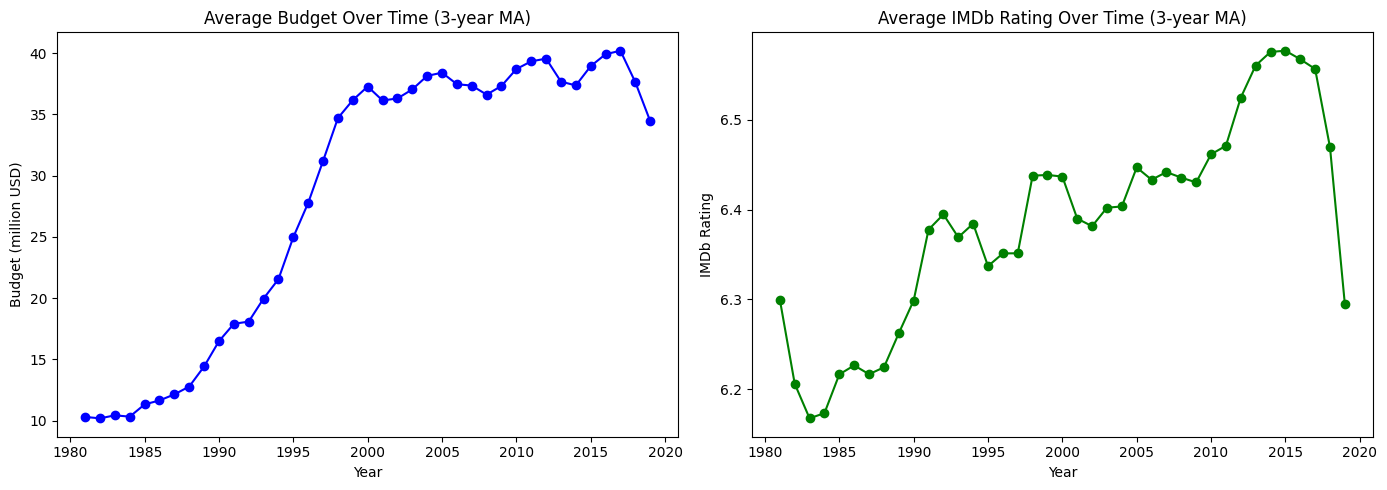


Average IMDb rating in 1980s: 6.219476567255022
Average IMDb rating in 2000s: 6.463478260869565
Conclusion: Slight decline, but not substantial; budgets increased dramatically.


In [29]:
df['release_year'] = df['release_year'].astype(int)
yearly = df.groupby('release_year').agg(
    avg_budget=('budget', 'mean'),
    avg_rating=('imdb_rating', 'mean')
).reset_index()
# 3-year moving average
yearly['budget_ma3'] = yearly['avg_budget'].rolling(3, center=True).mean()
yearly['rating_ma3'] = yearly['avg_rating'].rolling(3, center=True).mean()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(yearly['release_year'], yearly['budget_ma3'], marker='o', color='blue')
axes[0].set_title('Average Budget Over Time (3-year MA)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Budget (million USD)')
axes[1].plot(yearly['release_year'], yearly['rating_ma3'], marker='o', color='green')
axes[1].set_title('Average IMDb Rating Over Time (3-year MA)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('IMDb Rating')
plt.tight_layout()
plt.show()

print("\nAverage IMDb rating in 1980s:", df[df['release_year'] < 1990]['imdb_rating'].mean())
print("Average IMDb rating in 2000s:", df[df['release_year'] >= 2000]['imdb_rating'].mean())
print("Conclusion: Slight decline, but not substantial; budgets increased dramatically.")

 Task 5.3: Director Analysis

In [30]:
top_directors = df['director'].value_counts().head(10).index
director_stats = df[df['director'].isin(top_directors)].groupby('director').agg(
    movies=('title', 'count'),
    avg_rating=('imdb_rating', 'mean'),
    avg_profit=('profit_margin', 'mean')
).sort_values('movies', ascending=False)

print("\n--- Top 10 Directors by Number of Movies ---")
print(director_stats.round(3))

print("\nInterpretation: Directors like Steven Spielberg, Woody Allen, etc., appear most frequently; Spielberg also has high average profit and rating.")


--- Top 10 Directors by Number of Movies ---
                   movies  avg_rating  avg_profit
director                                         
Woody Allen            38       6.974       0.741
Clint Eastwood         31       6.968       2.269
Directors              28       6.546       4.591
Steven Spielberg       27       7.441       4.212
Ron Howard             24       6.825       2.110
Ridley Scott           23       6.926       0.944
Steven Soderbergh      23       6.678       2.838
Joel Schumacher        22       6.305       1.265
Barry Levinson         20       6.485       1.305
Martin Scorsese        19       7.674       0.852

Interpretation: Directors like Steven Spielberg, Woody Allen, etc., appear most frequently; Spielberg also has high average profit and rating.
